In [1]:
# 04_preprocessing.ipynb - Підготовка даних для моделей 

print("Підготовка даних для моделей")

import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from collections import Counter
import json
import joblib
from datetime import datetime

from src.config import DATA_DIR, FIGURES_DIR, MAX_SEQUENCE_LENGTH, RANDOM_SEED

%matplotlib inline

# Налаштування
plt.rcParams['figure.figsize'] = (12, 6)
(FIGURES_DIR / 'preprocessing').mkdir(parents=True, exist_ok=True)

print(f"Максимальна довжина послідовності: {MAX_SEQUENCE_LENGTH}")

Підготовка даних для моделей
Максимальна довжина послідовності: 9


In [2]:
print("Завантаження даних...")

from src.data_loader import load_clicks, load_buys

clicks = load_clicks()
buys = load_buys()

# Завантажуємо мітки якості
labels_df = pd.read_csv(DATA_DIR / 'session_labels.csv')
print(f" Мітки завантажено: {len(labels_df):,} сесій")

# Статистика завантажених даних
print(f"\n Дані:")
print(f"  Clicks: {len(clicks):,} записів")
print(f"  Buys: {len(buys):,} записів")
print(f"  Сесій з мітками: {len(labels_df):,}")

# Перевірка наявності всіх сесій у clicks
unique_sessions_clicks = clicks['Session_ID'].nunique()
unique_sessions_labels = labels_df['Session_ID'].nunique()
print(f"\n  Унікальних сесій в clicks: {unique_sessions_clicks:,}")
print(f"  Унікальних сесій в labels: {unique_sessions_labels:,}")

if unique_sessions_clicks != unique_sessions_labels:
    print(f"  Розбіжність: {abs(unique_sessions_clicks - unique_sessions_labels):,} сесій")

Завантаження даних...
 Мітки завантажено: 9,249,729 сесій

 Дані:
  Clicks: 33,003,944 записів
  Buys: 1,150,753 записів
  Сесій з мітками: 9,249,729

  Унікальних сесій в clicks: 9,249,729
  Унікальних сесій в labels: 9,249,729


In [3]:
print("Фільтрація даних")

# Фільтруємо clicks тільки для сесій, які є в labels
valid_sessions = labels_df['Session_ID'].unique()
clicks_filtered = clicks[clicks['Session_ID'].isin(valid_sessions)]

print(f"До фільтрації: {len(clicks):,} подій")
print(f"Після фільтрації: {len(clicks_filtered):,} подій")
print(f"Видалено: {len(clicks) - len(clicks_filtered):,} подій")

# Видаляємо дублікати
initial_count = len(clicks_filtered)
clicks_filtered = clicks_filtered.drop_duplicates()
dup_removed = initial_count - len(clicks_filtered)
print(f"Після видалення дублікатів: {len(clicks_filtered):,} подій (видалено {dup_removed:,})")

# Сортуємо по сесії та часу
clicks_filtered = clicks_filtered.sort_values(['Session_ID', 'Timestamp'])

# Додаємо порядок подій в сесії
clicks_filtered['event_order'] = clicks_filtered.groupby('Session_ID').cumcount() + 1

# Статистика після фільтрації
print(f"\n Дані відфільтровані та відсортовані")
print(f"  Унікальних сесій після фільтрації: {clicks_filtered['Session_ID'].nunique():,}")
print(f"  Середня кількість подій на сесію: {len(clicks_filtered) / clicks_filtered['Session_ID'].nunique():.2f}")

Фільтрація даних
До фільтрації: 33,003,944 подій
Після фільтрації: 33,003,944 подій
Видалено: 0 подій
Після видалення дублікатів: 33,003,876 подій (видалено 68)

 Дані відфільтровані та відсортовані
  Унікальних сесій після фільтрації: 9,249,729
  Середня кількість подій на сесію: 3.57


Аналіз довжини сесій для оптимізації

 Статистика довжини сесій:
  Мінімум: 1
  Медіана: 2
  Середня: 3.57
  90-й перцентиль: 7
  95-й перцентиль: 9
  99-й перцентиль: 18
  Максимум: 200

  Сесій, що будуть обрізані: 450,522 (4.87%)


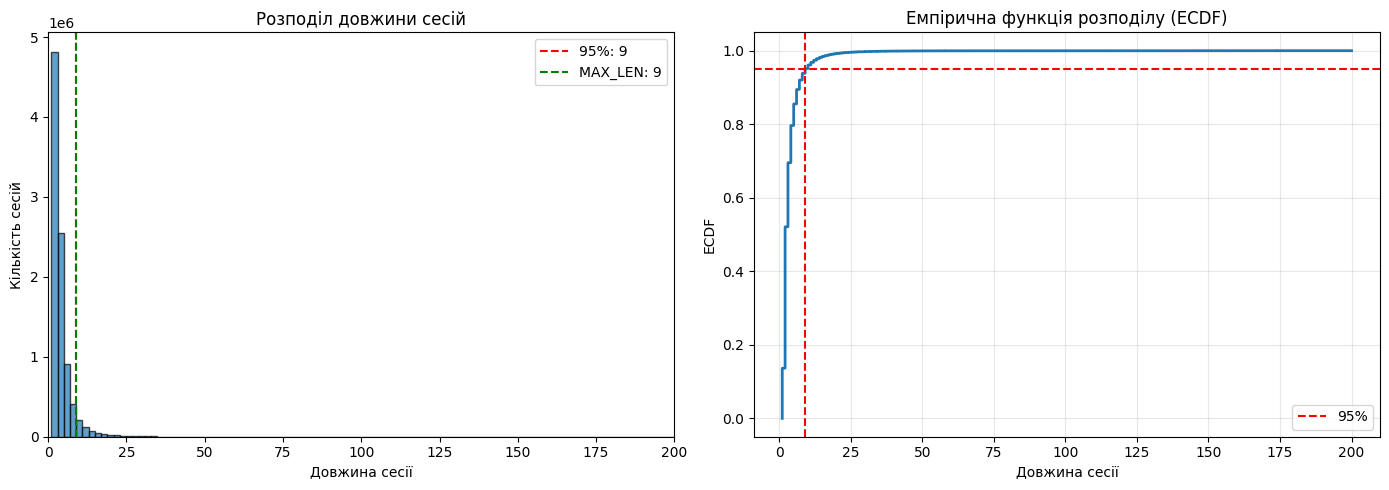


 Рекомендована MAX_SEQUENCE_LENGTH: 9
   Поточне значення оптимальне


In [4]:
print("Аналіз довжини сесій для оптимізації")

# Обчислюємо довжини сесій
session_lengths = clicks_filtered.groupby('Session_ID').size()

# Статистика
print(f"\n Статистика довжини сесій:")
print(f"  Мінімум: {session_lengths.min()}")
print(f"  Медіана: {session_lengths.median():.0f}")
print(f"  Середня: {session_lengths.mean():.2f}")
print(f"  90-й перцентиль: {session_lengths.quantile(0.90):.0f}")
print(f"  95-й перцентиль: {session_lengths.quantile(0.95):.0f}")
print(f"  99-й перцентиль: {session_lengths.quantile(0.99):.0f}")
print(f"  Максимум: {session_lengths.max()}")

# Кількість сесій, що будуть обрізані
truncated_sessions = (session_lengths > MAX_SEQUENCE_LENGTH).sum()
truncated_pct = truncated_sessions / len(session_lengths) * 100
print(f"\n  Сесій, що будуть обрізані: {truncated_sessions:,} ({truncated_pct:.2f}%)")

# Візуалізація
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гістограма з перцентилями
axes[0].hist(session_lengths, bins=100, edgecolor='black', alpha=0.7)
axes[0].axvline(session_lengths.quantile(0.95), color='red', linestyle='--', 
                label=f'95%: {session_lengths.quantile(0.95):.0f}')
axes[0].axvline(MAX_SEQUENCE_LENGTH, color='green', linestyle='--', 
                label=f'MAX_LEN: {MAX_SEQUENCE_LENGTH}')
axes[0].set_title('Розподіл довжини сесій')
axes[0].set_xlabel('Довжина сесії')
axes[0].set_ylabel('Кількість сесій')
axes[0].legend()
axes[0].set_xlim(0, 200)

# ECDF
sorted_lengths = np.sort(session_lengths)
ecdf = np.arange(1, len(sorted_lengths) + 1) / len(sorted_lengths)
axes[1].plot(sorted_lengths, ecdf, linewidth=2)
axes[1].axhline(0.95, color='red', linestyle='--', label='95%')
axes[1].axvline(session_lengths.quantile(0.95), color='red', linestyle='--')
axes[1].set_title('Емпірична функція розподілу (ECDF)')
axes[1].set_xlabel('Довжина сесії')
axes[1].set_ylabel('ECDF')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'preprocessing/session_length_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

# Рекомендація щодо MAX_LEN
recommended_max_len = int(session_lengths.quantile(0.95))
print(f"\n Рекомендована MAX_SEQUENCE_LENGTH: {recommended_max_len}")
if recommended_max_len != MAX_SEQUENCE_LENGTH:
    print(f"   Поточне значення ({MAX_SEQUENCE_LENGTH}) відрізняється від рекомендованого")
    print(f"  Рекомендується оновити src/config.py для оптимального використання пам'яті")
else:
    print(f"   Поточне значення оптимальне")

In [5]:
print("Кодування товарів")

# Кодуємо ID товарів
item_encoder = LabelEncoder()
clicks_filtered['item_encoded'] = item_encoder.fit_transform(clicks_filtered['Item_ID']) + 1  # +1 для padding (0)

vocab_size = clicks_filtered['item_encoded'].max() + 1  # +1 для padding (0)

print(f"Унікальних товарів: {len(item_encoder.classes_):,}")
print(f"Розмір словника (vocab_size): {vocab_size:,}")
print(f"   (включає 0 для padding)")

# Зберігаємо encoder для подальшого використання
joblib.dump(item_encoder, DATA_DIR / 'item_encoder.pkl')
print(f"Encoder збережено: {DATA_DIR / 'item_encoder.pkl'}")

# Статистика кодування
print(f"\nСтатистика кодування товарів:")
print(f"  Мінімальний код: {clicks_filtered['item_encoded'].min()}")
print(f"  Максимальний код: {clicks_filtered['item_encoded'].max()}")
print(f"  Середня частота товарів: {len(clicks_filtered) / vocab_size:.2f}")

# Показуємо приклад кодування
sample_items = clicks_filtered[['Item_ID', 'item_encoded']].drop_duplicates().head(10)
print(f"\nПриклад кодування (перші 10 унікальних товарів):")
print(sample_items.to_string(index=False))

Кодування товарів
Унікальних товарів: 52,739
Розмір словника (vocab_size): 52,740
   (включає 0 для padding)
Encoder збережено: d:\University\kursova\kursova\notebooks\..\data\yoochoose\item_encoder.pkl

Статистика кодування товарів:
  Мінімальний код: 1
  Максимальний код: 52739
  Середня частота товарів: 625.78

Приклад кодування (перші 10 унікальних товарів):
  Item_ID  item_encoded
214536502          2054
214536500          2053
214536506          2055
214577561          9877
214662742         19449
214825110         40789
214757390         32517
214757407         32523
214551617          4854
214716935         28990


In [6]:
print("Формування послідовностей")

def create_sequences_vectorized(df, max_len=MAX_SEQUENCE_LENGTH):
    """
    Оптимізоване створення послідовностей з кліків
    Використовує векторизовані операції замість циклів
    """
    # Групуємо по сесіях та збираємо списки товарів
    grouped = df.groupby('Session_ID')['item_encoded'].agg(list)
    session_ids = grouped.index.values
    items_lists = grouped.values
    
    print(f"Обробка {len(session_ids):,} сесій...")
    
    sequences = []
    truncated_count = 0
    padded_count = 0
    
    for items in items_lists:
        if len(items) > max_len:
            items = items[:max_len]
            truncated_count += 1
        elif len(items) < max_len:
            items = [0] * (max_len - len(items)) + items
            padded_count += 1
        sequences.append(items)
    
    print(f"  Обрізано сесій: {truncated_count:,} ({truncated_count/len(session_ids)*100:.2f}%)")
    print(f"  Доповнено сесій: {padded_count:,} ({padded_count/len(session_ids)*100:.2f}%)")
    
    return np.array(sequences), session_ids

# Створюємо послідовності
print("\n Створення послідовностей...")
X_sequences, session_ids_array = create_sequences_vectorized(clicks_filtered, MAX_SEQUENCE_LENGTH)

print(f"\n Послідовності створено:")
print(f"   Формат: {X_sequences.shape}")
print(f"   Кількість сесій: {len(session_ids_array):,}")

# Показуємо приклад
print(f"\n Приклад послідовності (перші 20 елементів):")
print(X_sequences[0][:20])

# Зберігаємо session_ids для довідки
np.save(DATA_DIR / 'session_ids.npy', session_ids_array)
print(f" Session IDs збережено: {DATA_DIR}/session_ids.npy")

Формування послідовностей

 Створення послідовностей...
Обробка 9,249,729 сесій...
  Обрізано сесій: 450,522 (4.87%)
  Доповнено сесій: 8,679,214 (93.83%)

 Послідовності створено:
   Формат: (9249729, 9)
   Кількість сесій: 9,249,729

 Приклад послідовності (перші 20 елементів):
[   0    0    0    0    0 2054 2053 2055 9877]
 Session IDs збережено: d:\University\kursova\kursova\notebooks\..\data\yoochoose/session_ids.npy


In [7]:
print("Отримання міток")

# Створюємо словник міток
labels_dict = dict(zip(labels_df['Session_ID'], labels_df['is_quality_session']))

# Отримуємо мітки для наших сесій
y_labels = np.array([labels_dict.get(sid, 0) for sid in session_ids_array])

# Статистика міток
positive_count = y_labels.sum()
negative_count = len(y_labels) - positive_count
positive_ratio = y_labels.mean() * 100

print(f"\n Мітки отримано:")
print(f"   Всього: {len(y_labels):,}")
print(f"   Якісні (1): {positive_count:,} ({positive_ratio:.2f}%)")
print(f"   Неякісні (0): {negative_count:,} ({100-positive_ratio:.2f}%)")

# Перевіряємо відповідність
print(f"\n Відповідність послідовностей та міток:")
print(f"   Послідовностей: {len(X_sequences):,}")
print(f"   Міток: {len(y_labels):,}")
assert len(X_sequences) == len(y_labels), "Розбіжність у кількості!"

# Додаткова перевірка: чи всі сесії мають мітки
missing_labels = sum(1 for sid in session_ids_array if sid not in labels_dict)
if missing_labels > 0:
    print(f"   Попередження: {missing_labels} сесій без міток (замінено на 0)")

Отримання міток

 Мітки отримано:
   Всього: 9,249,729
   Якісні (1): 509,608 (5.51%)
   Неякісні (0): 8,740,121 (94.49%)

 Відповідність послідовностей та міток:
   Послідовностей: 9,249,729
   Міток: 9,249,729


In [8]:
print("Розбиття на TRAIN/VAL/TEST")

from sklearn.model_selection import train_test_split

# Спочатку розбиваємо на train (70%) і temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_sequences, y_labels, 
    test_size=0.3, 
    random_state=RANDOM_SEED,
    stratify=y_labels  # зберігаємо співвідношення класів
)

# Потім temp ділимо на val (15%) і test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,  # 50% від temp = 15% від загалу
    random_state=RANDOM_SEED,
    stratify=y_temp
)

print(f"\n Розміри вибірок:")
print(f"  Train: {len(X_train):,} сесій ({len(X_train)/len(X_sequences)*100:.1f}%)")
print(f"  Val:   {len(X_val):,} сесій ({len(X_val)/len(X_sequences)*100:.1f}%)")
print(f"  Test:  {len(X_test):,} сесій ({len(X_test)/len(X_sequences)*100:.1f}%)")

print(f"\n Розподіл класів (збережено пропорції):")
print(f"  Train - якісні: {y_train.sum():,} ({y_train.mean()*100:.2f}%)")
print(f"  Val   - якісні: {y_val.sum():,} ({y_val.mean()*100:.2f}%)")
print(f"  Test  - якісні: {y_test.sum():,} ({y_test.mean()*100:.2f}%)")

# Перевірка збереження пропорцій
print(f"\n Перевірка стратифікації:")
print(f"  Початкова частка позитивних: {positive_ratio:.2f}%")
print(f"  Train частка: {y_train.mean()*100:.2f}%")
print(f"  Val частка:   {y_val.mean()*100:.2f}%")
print(f"  Test частка:  {y_test.mean()*100:.2f}%")

Розбиття на TRAIN/VAL/TEST

 Розміри вибірок:
  Train: 6,474,810 сесій (70.0%)
  Val:   1,387,459 сесій (15.0%)
  Test:  1,387,460 сесій (15.0%)

 Розподіл класів (збережено пропорції):
  Train - якісні: 356,726 (5.51%)
  Val   - якісні: 76,441 (5.51%)
  Test  - якісні: 76,441 (5.51%)

 Перевірка стратифікації:
  Початкова частка позитивних: 5.51%
  Train частка: 5.51%
  Val частка:   5.51%
  Test частка:  5.51%


In [9]:
print("Збереження даних")

# Зберігаємо в форматі .npy для швидкого завантаження
np.save(DATA_DIR / 'X_train.npy', X_train)
np.save(DATA_DIR / 'X_val.npy', X_val)
np.save(DATA_DIR / 'X_test.npy', X_test)
np.save(DATA_DIR / 'y_train.npy', y_train)
np.save(DATA_DIR / 'y_val.npy', y_val)
np.save(DATA_DIR / 'y_test.npy', y_test)

print(" Дані збережено у форматі .npy:")
print(f"  {DATA_DIR}/X_train.npy ({X_train.nbytes / 1024**3:.2f} GB)")
print(f"  {DATA_DIR}/X_val.npy ({X_val.nbytes / 1024**3:.2f} GB)")
print(f"  {DATA_DIR}/X_test.npy ({X_test.nbytes / 1024**3:.2f} GB)")
print(f"  {DATA_DIR}/y_train.npy")
print(f"  {DATA_DIR}/y_val.npy")
print(f"  {DATA_DIR}/y_test.npy")

# Зберігаємо метадані препроцесингу
preprocessing_info = {
    'timestamp': datetime.now().isoformat(),
    'total_sessions': int(len(session_ids_array)),
    'max_sequence_length': MAX_SEQUENCE_LENGTH,
    'vocab_size': int(vocab_size),
    'train_size': len(X_train),
    'val_size': len(X_val),
    'test_size': len(X_test),
    'train_positive_ratio': float(y_train.mean()),
    'val_positive_ratio': float(y_val.mean()),
    'test_positive_ratio': float(y_test.mean()),
    'random_seed': RANDOM_SEED,
    'unique_items': len(item_encoder.classes_),
    'truncated_sessions_count': int((session_lengths > MAX_SEQUENCE_LENGTH).sum()),
    'truncated_sessions_pct': float((session_lengths > MAX_SEQUENCE_LENGTH).sum() / len(session_lengths) * 100)
}

with open(DATA_DIR / 'preprocessing_info.json', 'w', encoding='utf-8') as f:
    json.dump(preprocessing_info, f, indent=4, ensure_ascii=False)

print(f"\n Метадані збережено: {DATA_DIR / 'preprocessing_info.json'}")

# Показуємо інформацію
print(f"\n Підсумки препроцесингу:")
for key, value in preprocessing_info.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.4f}")
    else:
        print(f"  {key}: {value}")

Збереження даних
 Дані збережено у форматі .npy:
  d:\University\kursova\kursova\notebooks\..\data\yoochoose/X_train.npy (0.43 GB)
  d:\University\kursova\kursova\notebooks\..\data\yoochoose/X_val.npy (0.09 GB)
  d:\University\kursova\kursova\notebooks\..\data\yoochoose/X_test.npy (0.09 GB)
  d:\University\kursova\kursova\notebooks\..\data\yoochoose/y_train.npy
  d:\University\kursova\kursova\notebooks\..\data\yoochoose/y_val.npy
  d:\University\kursova\kursova\notebooks\..\data\yoochoose/y_test.npy

 Метадані збережено: d:\University\kursova\kursova\notebooks\..\data\yoochoose\preprocessing_info.json

 Підсумки препроцесингу:
  timestamp: 2026-04-01T16:58:15.018431
  total_sessions: 9249729
  max_sequence_length: 9
  vocab_size: 52740
  train_size: 6474810
  val_size: 1387459
  test_size: 1387460
  train_positive_ratio: 0.0551
  val_positive_ratio: 0.0551
  test_positive_ratio: 0.0551
  random_seed: 42
  unique_items: 52739
  truncated_sessions_count: 450522
  truncated_sessions_pct: 

Статистика послідовнстей

 Статистика реальної довжини послідовностей:
  Середня: 3.24
  Медіана: 2
  Мінімум: 1
  Максимум: 9
  Обрізано (>9): 0 сесій

  Квантилі розподілу:
    25%: 2
    50%: 2
    75%: 4
    90%: 7
    95%: 9
    99%: 9


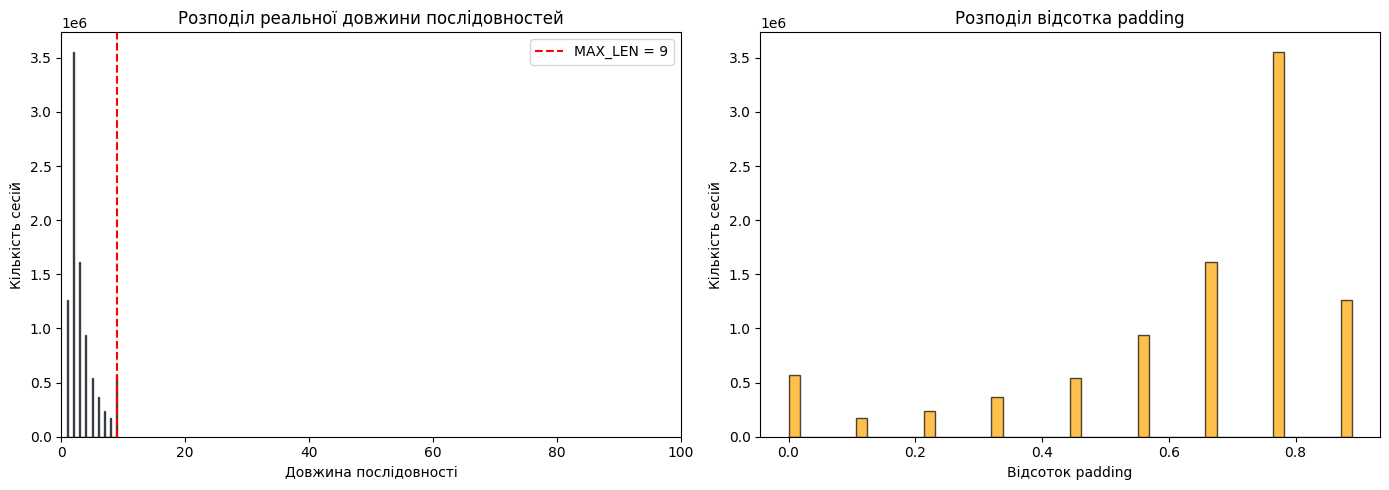


 Ефективність використання пам'яті:
  Середній відсоток padding: 64.0%
  Медіанний відсоток padding: 77.8%
  Загальний об'єм даних: 0.62 GB
  Корисні дані: 36.0%


In [10]:
print("Статистика послідовнстей")

# Векторизований аналіз довжини реальних послідовностей (без padding)
real_lengths = (X_sequences > 0).sum(axis=1)

print(f"\n Статистика реальної довжини послідовностей:")
print(f"  Середня: {real_lengths.mean():.2f}")
print(f"  Медіана: {np.median(real_lengths):.0f}")
print(f"  Мінімум: {real_lengths.min()}")
print(f"  Максимум: {real_lengths.max()}")
print(f"  Обрізано (>{MAX_SEQUENCE_LENGTH}): {(real_lengths > MAX_SEQUENCE_LENGTH).sum():,} сесій")

# Квантилі для детального аналізу
quantiles = [0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
print(f"\n  Квантилі розподілу:")
for q in quantiles:
    print(f"    {q*100:.0f}%: {np.quantile(real_lengths, q):.0f}")

# Візуалізація
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Розподіл реальних довжин
axes[0].hist(real_lengths, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(MAX_SEQUENCE_LENGTH, color='red', linestyle='--', 
                label=f'MAX_LEN = {MAX_SEQUENCE_LENGTH}')
axes[0].set_title('Розподіл реальної довжини послідовностей')
axes[0].set_xlabel('Довжина послідовності')
axes[0].set_ylabel('Кількість сесій')
axes[0].legend()
axes[0].set_xlim(0, 100)

# Відсоток заповнення (скільки padding)
padding_ratio = 1 - (real_lengths / MAX_SEQUENCE_LENGTH)
axes[1].hist(padding_ratio, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title('Розподіл відсотка padding')
axes[1].set_xlabel('Відсоток padding')
axes[1].set_ylabel('Кількість сесій')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'preprocessing/sequence_stats.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\n Ефективність використання пам'яті:")
print(f"  Середній відсоток padding: {padding_ratio.mean()*100:.1f}%")
print(f"  Медіанний відсоток padding: {np.median(padding_ratio)*100:.1f}%")
print(f"  Загальний об'єм даних: {X_sequences.nbytes / 1024**3:.2f} GB")
print(f"  Корисні дані: {real_lengths.sum() / MAX_SEQUENCE_LENGTH / len(X_sequences) * 100:.1f}%")

In [11]:
print("Валідація даних")

# Перевіряємо відсутність NaN
assert not np.isnan(X_train).any(), "Є NaN в X_train"
assert not np.isnan(y_train).any(), "Є NaN в y_train"
assert not np.isnan(X_val).any(), "Є NaN в X_val"
assert not np.isnan(X_test).any(), "Є NaN в X_test"

print("Немає NaN значень")

# Перевіряємо коректність значень
assert X_train.min() >= 0, "Є від'ємні значення"
assert X_train.max() < vocab_size, f"Значення перевищують vocab_size ({vocab_size})"

print("Всі значення в коректному діапазоні")

# Перевіряємо типи даних
print(f"\nТипи даних:")
print(f"  X_train: {X_train.dtype}")
print(f"  y_train: {y_train.dtype}")

# Перевіряємо форми
print(f"\nФорми:")
print(f"  X_train: {X_train.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape}")
print(f"  X_test:  {X_test.shape}")

# Перевірка балансу класів у всіх вибірках
print(f"\nБаланс класів:")
print(f"  Train: {y_train.sum():,}/{len(y_train):,} ({y_train.mean()*100:.2f}%)")
print(f"  Val:   {y_val.sum():,}/{len(y_val):,} ({y_val.mean()*100:.2f}%)")
print(f"  Test:  {y_test.sum():,}/{len(y_test):,} ({y_test.mean()*100:.2f}%)")

print("Препроцесинг успішно звершений")

Валідація даних
Немає NaN значень
Всі значення в коректному діапазоні

Типи даних:
  X_train: int64
  y_train: int64

Форми:
  X_train: (6474810, 9)
  y_train: (6474810,)
  X_val:   (1387459, 9)
  X_test:  (1387460, 9)

Баланс класів:
  Train: 356,726/6,474,810 (5.51%)
  Val:   76,441/1,387,459 (5.51%)
  Test:  76,441/1,387,460 (5.51%)
Препроцесинг успішно звершений


In [ ]:
print("Агреговані ознаки для BASELINE")

from collections import Counter

def extract_sequence_features_vectorized(sequences):
    features = []
    
    for seq in sequences:
        real_seq = seq[seq > 0]
        
        if len(real_seq) > 0:
            unique_items = len(np.unique(real_seq))
            diversity = unique_items / len(real_seq)
            repeat_ratio = 1 - diversity
            
            counter = Counter(real_seq)
            most_common_ratio = counter.most_common(1)[0][1] / len(real_seq)
            
            feat = {
                'length': len(real_seq),
                'unique_items': unique_items,
                'diversity': diversity,
                'repeat_ratio': repeat_ratio,
                'most_common': most_common_ratio,
                'first_item': real_seq[0],
                'last_item': real_seq[-1],
            }
        else:
            feat = {
                'length': 0,
                'unique_items': 0,
                'diversity': 0,
                'repeat_ratio': 0,
                'most_common': 0,
                'first_item': 0,
                'last_item': 0,
            }
        
        features.append(feat)
    
    return pd.DataFrame(features)

# Перевіряємо, чи існують змінні з послідовностями
try:
    print(f"Створення агрегованих ознак...")
    print(f"  Обробка Train ({len(X_train):,} сесій)...")
    X_train_features = extract_sequence_features_vectorized(X_train)
    
    print(f"  Обробка Val ({len(X_val):,} сесій)...")
    X_val_features = extract_sequence_features_vectorized(X_val)
    
    print(f"  Обробка Test ({len(X_test):,} сесій)...")
    X_test_features = extract_sequence_features_vectorized(X_test)
    
    print(f"\n Ознаки створено:")
    print(f"  Train: {X_train_features.shape}")
    print(f"  Val:   {X_val_features.shape}")
    print(f"  Test:  {X_test_features.shape}")
    
    # Зберігаємо ознаки
    X_train_features.to_csv(DATA_DIR / 'X_train_features.csv', index=False)
    X_val_features.to_csv(DATA_DIR / 'X_val_features.csv', index=False)
    X_test_features.to_csv(DATA_DIR / 'X_test_features.csv', index=False)
    
    print(f"\n Агреговані ознаки збережено:")
    print(f"  {DATA_DIR}/X_train_features.csv")
    print(f"  {DATA_DIR}/X_val_features.csv")
    print(f"  {DATA_DIR}/X_test_features.csv")
    
    # Показуємо приклад
    print(f"\n Приклад ознак (перші 5 рядків):")
    display(X_train_features.head())
    
    # Статистика ознак
    print(f"\n Статистика ознак (Train):")
    display(X_train_features.describe())
    
except NameError as e:
    print(f" Помилка: {e}")
    print("   Переконайтеся, що ця комірка виконується ПІСЛЯ комірки 8 (розбиття на train/val/test)")

Агреговані ознаки для BASELINE
Створення агрегованих ознак...
  Обробка Train (6,474,810 сесій)...
  Обробка Val (1,387,459 сесій)...
  Обробка Test (1,387,460 сесій)...

 Ознаки створено:
  Train: (6474810, 7)
  Val:   (1387459, 7)
  Test:  (1387460, 7)

 Агреговані ознаки збережено:
  d:\University\kursova\kursova\notebooks\..\data\yoochoose/X_train_features.csv
  d:\University\kursova\kursova\notebooks\..\data\yoochoose/X_val_features.csv
  d:\University\kursova\kursova\notebooks\..\data\yoochoose/X_test_features.csv

 Приклад ознак (перші 5 рядків):


,length,unique_items,diversity,repeat_ratio,most_common,first_item,last_item
0,2,2,1.000000,0.000000,0.500000,13010,518
1,2,1,0.500000,0.500000,1.000000,41225,41225
2,7,4,0.571429,0.428571,0.285714,5755,7739
3,3,3,1.000000,0.000000,0.333333,48713,29057
4,2,2,1.000000,0.000000,0.500000,41174,41176



 Статистика ознак (Train):


,length,unique_items,diversity,repeat_ratio,most_common,first_item,last_item
count,6.474810e+06,6.474810e+06,6.474810e+06,6.474810e+06,6.474810e+06,6.474810e+06,6.474810e+06
mean,3.243382e+00,2.658923e+00,8.535265e-01,1.464735e-01,5.755864e-01,3.373697e+04,3.310084e+04
std,2.155977e+00,1.813189e+00,2.178339e-01,2.178339e-01,2.872802e-01,1.630405e+04,1.632696e+04
min,1.000000e+00,1.000000e+00,1.111111e-01,0.000000e+00,1.111111e-01,1.000000e+00,1.000000e+00
25%,2.000000e+00,1.000000e+00,6.666667e-01,0.000000e+00,3.333333e-01,2.072800e+04,2.021800e+04
50%,2.000000e+00,2.000000e+00,1.000000e+00,0.000000e+00,5.000000e-01,4.182200e+04,4.122100e+04
75%,4.000000e+00,3.000000e+00,1.000000e+00,3.333333e-01,1.000000e+00,4.763300e+04,4.749300e+04
max,9.000000e+00,9.000000e+00,1.000000e+00,8.888889e-01,1.000000e+00,5.273900e+04,5.273900e+04
